<a href="https://colab.research.google.com/github/Spai06/AI-vs-Human-CNN-Photo-Detection/blob/main/AI_vs_Human_CNN_Photo_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**First, we'll import the main libraries we need for setup, data handling, and plotting. We'll also use the kagglehub library to download our dataset directly.**

In [ ]:
import kagglehub
import os
import torch
import torchvision
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

print("Downloading dataset from Kaggle...")
dataset_path = kagglehub.dataset_download("xhlulu/140k-real-and-fake-faces")
print(f"Dataset downloaded to: {dataset_path}")

Using Colab cache for faster access to the '140k-real-and-fake-faces' dataset.
Dataset downloaded to: /kaggle/input/140k-real-and-fake-faces


**Now for data exploration and preprocessing, basically before we train our model, we want to see how all the images are organised within the directory. So for example this will help us confirm the classes are our model is trying to learn which is real vs fake while also confirming the location of the testing and training images.**

In [ ]:
# Look into the data directory
data_dir = "/kaggle/input/140k-real-and-fake-faces/real_vs_fake/real-vs-fake"
#Our colab is running in a kaggle environment not locally on our laptop, so our data directory will be as stated above
print(f"Root data directory contains: {os.listdir(data_dir)}")
classes = os.listdir(data_dir + "/train")
print(f"Training classes found: {classes}")

Root data directory contains: ['valid', 'test', 'train']
Training classes found: ['fake', 'real']


**Now we must resize the images and apply the image transformations which we will have defined as train_tfms and valid_tfms. We use the Resize method to convert all images to being the dimensions of 64x64 as they all must be the same and also the toTensor function which allows for the model to learn the underlying patterns in a format it is comfortable with which is a PyTorch Tensor which it can learn the patterns easily. It scales all pixel values from 0-255 to 0.0-1.0 which is in the end more efficient for training.**

In [ ]:
from torchvision.datasets import ImageFolder
import torchvision.transforms as tt

train_tfms = tt.Compose([tt.ToTensor(),tt.Resize((64,64), antialias=True)])
valid_tfms = tt.Compose([tt.ToTensor(), tt.Resize((64,64), antialias=True)])

**Now what we can do is we can use the ImageFolder class from PyTorch to create the main datasets. What this means is ImageFolder will automatically find all the images, assign the correct labels based on the subfolder name so for example /fake will get fake label and also applies all the transformations effiently.**

In [ ]:
# PyTorch datasets
train_ds = ImageFolder(data_dir+'/train', train_tfms)
valid_ds = ImageFolder(data_dir+'/test', valid_tfms)

print(f"No. of training examples: {len(train_ds)}")
print(f"No. of validation examples: {len(valid_ds)}")

No. of training examples: 100000
No. of validation examples: 20000


**Now we need to load the data and visualise, basically we can set a batch size and use the DataLoader function. DataLoader is a life saver because what it does is instead of trying to forcefeed the large dataset of images into the model to learn at once, the DataLoader will feed the data into groups of our batch size into the machine at a time which makes it more memory efficient and helps the model learn better in general which is also a process known as stochastic gradient descent.**

In [ ]:
##
from torch.utils.data import DataLoader

batch_size=32

# PyTorch data loaders
# Set num_workers=2 (or more) to speed up loading, pin_memory=True for faster GPU transfer
train_dl = DataLoader(train_ds, batch_size, shuffle=True, num_workers=2, pin_memory=True)
valid_dl = DataLoader(valid_ds, batch_size*2, num_workers=2, pin_memory=True)

# Check a batch
for images, labels in train_dl:
    print(f"Images batch shape: {images.shape}")
    print(f"Labels batch shape: {labels.shape}")
    break

Images batch shape: torch.Size([32, 3, 64, 64])
Labels batch shape: torch.Size([32])


**Now we can do a little sanity check for ourselves as we can create a small helper function to print one of the batches to the console and display in a grid to check that our code is actually working as intended. It makes sure that the images are being correctly loaded, transformed etc before we begin our training process**

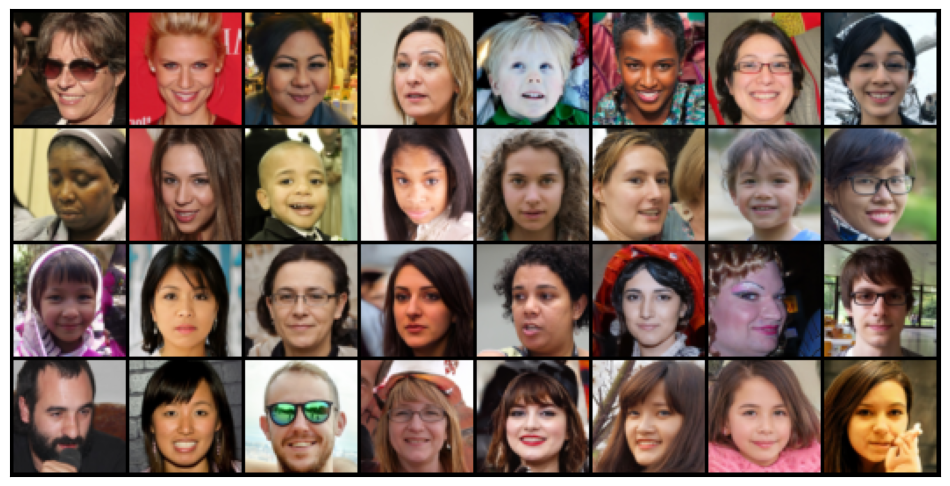

In [ ]:
from torchvision.utils import make_grid

def show_batch(dl):
    for images, labels in dl:
        fig, ax = plt.subplots(figsize=(12, 12))
        ax.set_xticks([]); ax.set_yticks([])
        ax.imshow(make_grid(images[:64], nrow=8).permute(1, 2, 0).clamp(0,1))
        break

show_batch(train_dl)

**Now we need to set up our device, basically most of the time we want this program to run on our GPU because it is much more powerful and able to handle it, however certain devices may not allow it and hence will run on CPU which still works but might take a little longer to train etc. So we check if cuda which is GPU is available. CPU will work just take much longer and GPU is able to complete thousands of times faster.**

In [ ]:
# Pick device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


**So now what we can do is create another helper function to_device and a class called DeviceLoader which basically lets us automatically move our batches of data into the device that is selected so CPU or GPU when only they are needed. So instead of manually doing it in the training loop for each batch, it is done automatically and out of the training loop which becomes much more efficient.**

In [ ]:
# Move data or model to device
def to_device(data):
    if isinstance(data, (list, tuple)):
        return [x.to(device, non_blocking=True) for x in data]
    return data.to(device, non_blocking=True)

# Wrap DataLoader to automatically move batches
class DeviceLoader:
    def __init__(self, dl):
        self.dl = dl
    def __iter__(self):
        for batch in self.dl:
            yield to_device(batch)
    def __len__(self):
        return len(self.dl)

# Apply
train_dl = DeviceLoader(train_dl)
valid_dl = DeviceLoader(valid_dl)

**Now what we can do is define the class our main model wil inherit from which is called ImageClassificationBase. This class will include:
- training_step: calculating the loss for one batch of training data
- validation_step: calculates the loss and gets the labels for one batch of validation data
- validation_epoch_end: gathers all the validation results after an epoch and calculates average loss, accuracy, precision etc.
- epoch_end: prints the formatted log of all results after the epoch ends
- metrics: helper function for calculating accuracy, precision, f1-score etc using the sklearn.metrics module. We can use a sigmoid >= 0.5 to get the final prediction. The sigmoid basically maps the result to a prbability value between 0.0 to 1.

In [ ]:
##
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def metrics(outputs, labels):
    # Convert outputs (probabilities) to 0 or 1 predictions
    preds = (outputs >= 0.5).float().cpu().detach().numpy()
    labels = labels.cpu().detach().numpy()

    accuracy = accuracy_score(labels, preds)
    precision = precision_score(labels, preds, zero_division=0)
    recall = recall_score(labels, preds, zero_division=0)
    f1 = f1_score(labels, preds, zero_division=0)

    return {
        'accuracy': torch.tensor(accuracy, device=outputs.device),
        'precision': torch.tensor(precision, device=outputs.device),
        'recall': torch.tensor(recall, device=outputs.device),
        'f1_score': torch.tensor(f1, device=outputs.device)}

class ImageClassificationBase(nn.Module):

    def training_step(self, batch):
        images, labels = batch
        labels = labels.unsqueeze(1).float() # Add a dimension for binary cross entropy
        out = self(images)                  # Generate predictions
        loss = F.binary_cross_entropy(out, labels) # Calculate loss
        return loss

    def validation_step(self, batch):
        images, labels = batch
        labels = labels.unsqueeze(1).float()
        out = self(images)                    # Generate predictions
        loss = F.binary_cross_entropy(out, labels)   # Calculate loss

        return {
            'val_loss': loss.detach(),
            'outputs': out.detach().cpu(), # Detach from graph, move to CPU for metrics
            'labels': labels.detach().cpu()}

    def validation_epoch_end(self, outputs):
        # Combine all batch losses and metrics
        batch_losses = [x['val_loss'] for x in outputs]
        epoch_loss = torch.stack(batch_losses).mean()

        all_outputs = torch.cat([x['outputs'] for x in outputs], dim=0)
        all_labels = torch.cat([x['labels'] for x in outputs], dim=0)

        metric_values = metrics(all_outputs, all_labels)

        return {
            'val_loss': epoch_loss.item(),
            'val_acc': metric_values['accuracy'].item(),
            'val_precision': metric_values['precision'].item(),
            'val_recall': metric_values['recall'].item(),
            'val_f1': metric_values['f1_score'].item()}

    def epoch_end(self, epoch, result):
        # Print results at the end of each epoch
        print("Epoch [{}], last_lr: {:.4f}, train_loss: {:.4f}, val_loss: {:.4f}, val_acc: {:.4f}, val_prec: {:.4f}, val_rec: {:.4f}, val_f1: {:.4f}".format(
            epoch, result['lrs'][-1], result['train_loss'], result['val_loss'],
            result['val_acc'], result['val_precision'], result['val_recall'], result['val_f1']))

**Now we have to define our actual CNN model, The model is made up of layers on layers to help identify the smallest of patterns in the images to differentiate between fake and real. Basically we have a few components:
- nn.Conv2d(the convolutional layer): This is the eye of the network, it scans the images with small filters to detect simple objects like edgers, corners, textures etc
- nn.BatchNorm2d (batch norm): which is basically used to speed up the training process and also stabilize the learning process.
- F.leaky_relu (Activation Function): This acts as a switch to be on or off which includes non-linearity to our model. In other words, non-linearity allows the model to learn more complex patterns.
- nn.AvgPool2d/nn.MaxPool2d (pooling layer): In this pooling layer, what it does is it makes the image smaller and downsized, which then reduces the amount of search and computation the model must do to find/ learn the important features and instead can focus more simply on the important features.
- nn.Linear (Fully Connected Layer): This acts as the brain of the network, after the model has detected all the features it needs to differentiate, these layers take the final detected features and make the decision.
- nn.Dropout: A regularisation technique which is used to randomly turn on or off some neurons during the training process which prevents overfitting or the model from only memorising the training data. It acts as a surprise filter basically.
- torch.sigmoid: the final output layer since the output is binary as fake or real, the sigmoid turns the output to be a number between 0 and 1, this is interpreted as the probability the image is real. So if 0.8 then 80% chance the image is real.

In [ ]:
##
class CNNModel(ImageClassificationBase):
    def __init__(self):
        super(CNNModel, self).__init__()

        # Convolutional Layers
        self.conv1 = nn.Conv2d(3, 8, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(8)

        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(16, 16, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(16)
        self.pool1 = nn.AvgPool2d(2, 2)

        self.conv4 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv5 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(32)
        self.pool2 = nn.AvgPool2d(2, 2)

        self.conv6 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv7 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.conv8 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.conv9 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(64)
        self.pool3 = nn.AvgPool2d(2, 2)

        self.conv10 = nn.Conv2d(64, 128, kernel_size=5, padding=2)
        self.bn5 = nn.BatchNorm2d(128)
        self.pool4 = nn.MaxPool2d(2, 2)

        self.conv11 = nn.Conv2d(128, 256, kernel_size=5, padding=2)
        self.bn6 = nn.BatchNorm2d(256)
        self.pool5 = nn.MaxPool2d(2, 2)

        # Fully Connected Layers
        self.fc1 = nn.Linear(256, 32)
        self.fc2 = nn.Linear(32, 16)
        self.fc3 = nn.Linear(16, 1)

        # Dropout
        self.dropout = nn.Dropout(0.5)

    #Always needs a forward function for any neural network.
    def forward(self, x):
        # This forward pass is quite complex, stacking multiple layers.
        x = self.pool1(F.leaky_relu(self.bn1(self.conv1(x))))
        x = self.pool1(F.leaky_relu(self.bn2(self.conv3(F.leaky_relu(self.conv2(x))))))
        x = self.pool2(F.leaky_relu(self.bn3(self.conv5(F.leaky_relu(self.conv4(x))))))
        x = self.pool3(F.leaky_relu(self.bn4(self.conv9(F.leaky_relu(self.conv8(F.leaky_relu(self.conv7(F.leaky_relu(self.conv6(x))))))))))
        x = self.pool4(F.leaky_relu(self.bn5(self.conv10(x))))
        x = self.pool5(F.leaky_relu(self.bn6(self.conv11(x))))

        # Flatten for the fully connected layers
        x = torch.flatten(x, 1)
        x = self.dropout(F.leaky_relu(self.fc1(x)))
        x = self.dropout(F.leaky_relu(self.fc2(x)))
        x = self.fc3(x)

        # Apply sigmoid to get a 0-1 probability
        return torch.sigmoid(x)

In [ ]:
#We can now create an instance of our model and move it to our aforementioned device which is either CPU or GPU
model = to_device(CNNModel())
model

CNNModel(
  (conv1): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (conv4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv5): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (conv6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv7): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv8): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1

**Now we need to actually begin the training process of the machine learning model. We need some helper functions to make this entire loop much more simpler which include:
- evaluate: Running the model on the validation set and returning the relevant metrics
- get_lr: Which gets the current learning rate from the optimiser
- save_checkpoint/load_checkpoint: Instead of having to run the program from scratch every single time, this saves our progress after each epoch and resumes training from a certain point if interrupted.
- fit_one_cycle: This is the main function for our training it loops for the number of epochs and in each epoch:
  - goes through every batch in train_loader
  - calculates the loss and uses the optimiser to update the weights of the model
  - uses OneCyleLR schedular to gradually increase the LR and then decrease it which is used for stable, efficient and better training
  - calls evaluate to check performance on val_loader
  - logs the results and saves to the checkpoint


In [ ]:

from tqdm import tqdm
CHECKPOINT_PATH = "model_checkpoint_deepcnn.pth"

@torch.no_grad()
def evaluate(model, val_loader):
    model.eval()
    outputs = [model.validation_step(batch) for batch in val_loader]
    return model.validation_epoch_end(outputs)

def get_lr(optimizer):
    return optimizer.param_groups[0]['lr']

def save_checkpoint(epoch, model, optimizer, scheduler, history):
    """Save model checkpoint locally."""
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),  # Save scheduler
        'history': history
    }, CHECKPOINT_PATH)
    print(f"Checkpoint saved at epoch {epoch+1}")


def load_checkpoint(model, optimizer, scheduler):
    """Load model checkpoint if available."""
    if os.path.exists(CHECKPOINT_PATH):
        checkpoint = torch.load(CHECKPOINT_PATH, map_location=torch.device('cuda' if torch.cuda.is_available() else 'cpu'))
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])  # Load scheduler
        history = checkpoint['history']
        start_epoch = checkpoint['epoch'] + 1

        # Ensure correct LR after restoring
        for param_group in optimizer.param_groups:
            param_group['lr'] = get_lr(optimizer)

        print(f"Resuming training from epoch {start_epoch}, with LR: {get_lr(optimizer)}")
        return start_epoch, history
    return 0, []

def fit_one_cycle(epochs, max_lr, model, train_loader, val_loader,
                  weight_decay=0, grad_clip=None, opt_func=torch.optim.Adam):
    torch.cuda.empty_cache()

    optimizer = opt_func(model.parameters(), lr=max_lr, weight_decay=weight_decay)

    # Define OneCycleLR scheduler
    sched = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr, epochs=epochs,
                                                steps_per_epoch=len(train_loader))

    # Load checkpoint if available
    start_epoch, history = load_checkpoint(model, optimizer, sched)

    for epoch in range(start_epoch, epochs):  # Start from last saved epoch
        model.train()
        train_losses = []
        lrs = []

        with tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", unit="batch") as pbar:
            for batch in pbar:
                loss = model.training_step(batch)
                train_losses.append(loss)
                loss.backward()

                if grad_clip:
                    nn.utils.clip_grad_value_(model.parameters(), grad_clip)

                optimizer.step()
                sched.step()  # Move AFTER optimizer step
                optimizer.zero_grad()

                lrs.append(get_lr(optimizer))
                pbar.set_postfix(loss=loss.item(), lr=lrs[-1])

        # Validation
        result = evaluate(model, val_loader)
        result['train_loss'] = torch.stack(train_losses).mean().item()
        result['lrs'] = lrs
        model.epoch_end(epoch, result)
        history.append(result)

        # Save checkpoint
        save_checkpoint(epoch, model, optimizer, sched, history)

    return history

**Now we need to evaluate our model on the validation set before training, the untrained model should normally have an accuracy of about 40-50% to confirm that our model isnt stuck or functioning properly.**


In [ ]:
# Clear checkpoint file if you want to train from scratch
# if os.path.exists(CHECKPOINT_PATH):
#     os.remove(CHECKPOINT_PATH)
#     print("Removed old checkpoint.")

history = [evaluate(model, valid_dl)]
history

[{'val_loss': 0.6937142014503479,
  'val_acc': 0.5,
  'val_precision': 0.0,
  'val_recall': 0.0,
  'val_f1': 0.0}]

**Now we set up the hyper parameters and actually begin our training. What we will do here is set up our settings for an ideal training session and then record:
epochs: which is how many iterations will be completed
max_lr: the peak learning rate for the OneCyclerLR scheduler reaches
grad_clip: prevents the gradients from getting too large and hence would destabilise our training
weight_decay: a regularisation technique also used to prevent overfitting
opt_func: Using the AdamW optimiser which is very advanced and effective in these type of projects

In [ ]:
epochs = 11
max_lr = 0.005
grad_clip = 0.1
weight_decay = 1e-4
opt_func = torch.optim.AdamW


In [ ]:
%%time
history += fit_one_cycle(epochs, max_lr, model, train_dl, valid_dl,
                             grad_clip=grad_clip,
                             weight_decay=weight_decay,
                             opt_func=opt_func)

Epoch 1/11: 100%|██████████| 3125/3125 [08:46<00:00,  5.93batch/s, loss=0.564, lr=0.00121]


Epoch [0], last_lr: 0.0012, train_loss: 0.5923, val_loss: 0.5165, val_acc: 0.7436, val_prec: 0.7625, val_rec: 0.7076, val_f1: 0.7340
Checkpoint saved at epoch 1


Epoch 2/11: 100%|██████████| 3125/3125 [03:32<00:00, 14.72batch/s, loss=0.455, lr=0.00339]


Epoch [1], last_lr: 0.0034, train_loss: 0.4946, val_loss: 0.4703, val_acc: 0.7829, val_prec: 0.7166, val_rec: 0.9360, val_f1: 0.8118
Checkpoint saved at epoch 2


Epoch 3/11: 100%|██████████| 3125/3125 [03:34<00:00, 14.55batch/s, loss=0.423, lr=0.0049]


...

Epoch [8], last_lr: 0.0008, train_loss: 0.1170, val_loss: 0.1396, val_acc: 0.9498, val_prec: 0.9470, val_rec: 0.9529, val_f1: 0.9500
Checkpoint saved at epoch 9


Epoch 10/11: 100%|██████████| 3125/3125 [03:31<00:00, 14.80batch/s, loss=0.105, lr=0.000205]


Epoch [9], last_lr: 0.0002, train_loss: 0.0865, val_loss: 0.1448, val_acc: 0.9521, val_prec: 0.9444, val_rec: 0.9609, val_f1: 0.9526
Checkpoint saved at epoch 10


Epoch 11/11: 100%|██████████| 3125/3125 [03:31<00:00, 14.76batch/s, loss=0.127, lr=2e-8]


Epoch [10], last_lr: 0.0000, train_loss: 0.0680, val_loss: 0.1654, val_acc: 0.9518, val_prec: 0.9488, val_rec: 0.9552, val_f1: 0.9520
Checkpoint saved at epoch 11
CPU times: user 8min 19s, sys: 44.2 s, total: 9min 3s
Wall time: 51min 25s


**Analysing the result, we can plot the validation accuracy from the history object, and we can now observe how the accuracy of the model has increased after each epoch checking if the model is actually learning or not.**

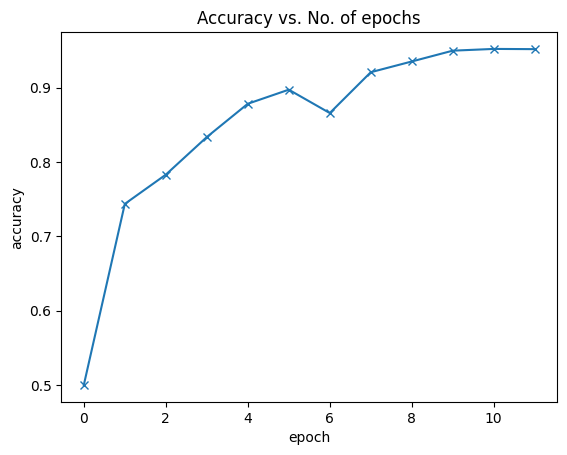

In [ ]:
def plot_accuracies(history):
    accuracies = [x['val_acc'] for x in history]
    plt.plot(accuracies, '-x')
    plt.xlabel('epoch')
    plt.ylabel('accuracy')
    plt.title('Accuracy vs. No. of epochs');

plot_accuracies(history)

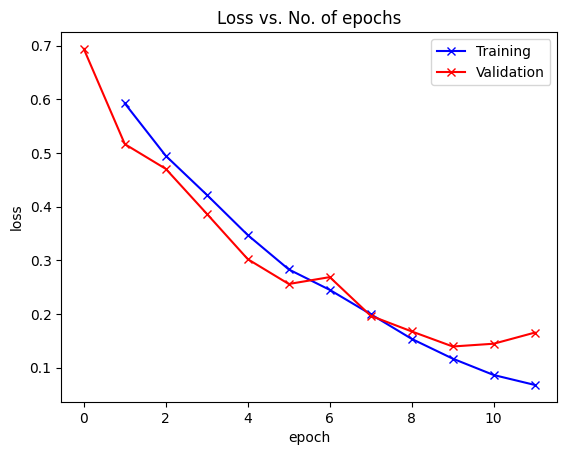

In [ ]:
#We can now plot both the training and validation loss because this will help us diagnose the model in most importance. The training loss which is blue, should in ideal always decrease whereas the validation loss should also decrease
#However, if it starts to go up, while the training loss is decreasing then it is a clear sign of overfitting.
def plot_losses(history):
    train_losses = [x.get('train_loss') for x in history]
    val_losses = [x['val_loss'] for x in history]
    plt.plot(train_losses, '-bx')
    plt.plot(val_losses, '-rx')
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.legend(['Training', 'Validation'])
    plt.title('Loss vs. No. of epochs');

plot_losses(history)

**We can also plot the learning rate that was adjusted by the OneCycle Scheduler for each batch during the training. This visualises what the OneCycle actually did which was basically warming up the lr from our low value to our maximum learning rate and then gradually back down which helps the model to learn efficiently and accurately with a stable solution.**

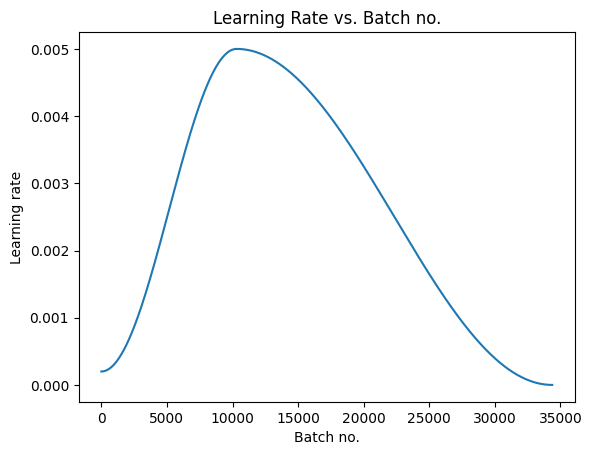

In [ ]:
def plot_lrs(history):
    lrs = np.concatenate([x.get('lrs', []) for x in history])
    plt.plot(lrs)
    plt.xlabel('Batch no.')
    plt.ylabel('Learning rate')
    plt.title('Learning Rate vs. Batch no.');

plot_lrs(history)

**We can define a function called predict_image to help test our model on certain images from our validation set. Basically in other words we are just double checking with our model that it can correctly identify whether an image is fake or real on a specific example.**

Label: fake , Predicted: fake


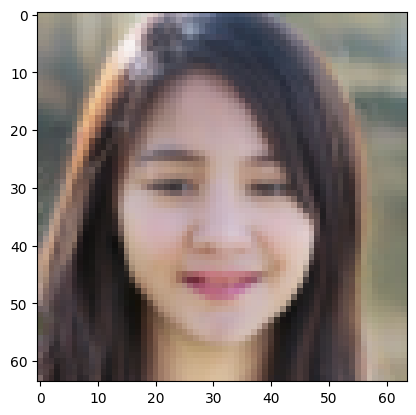

In [ ]:
## 32,3,64,64  1,3,64,64
def predict_image(img, model):
    # Convert to a batch of 1
    xb = to_device(img.unsqueeze(0))
    # Get predictions from model
    yb = model(xb)
    # Get the predicted class (0 for fake, 1 for real)
    pred = (yb >= 0.5).float().item()
    # Retrieve the class label
    return train_ds.classes[int(pred)]

# Test on a 'fake' image
img, label = valid_ds[0]
plt.imshow(img.permute(1, 2, 0).clamp(0, 1))
print('Label:', train_ds.classes[label], ', Predicted:', predict_image(img, model))


Label: real , Predicted: real


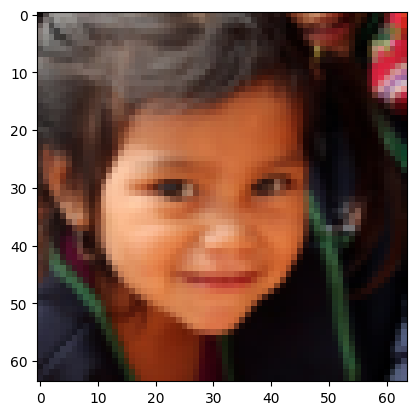

In [ ]:
# Test on a 'real' image
img, label = valid_ds[10002]
plt.imshow(img.permute(1, 2, 0).clamp(0, 1))
print('Label:', valid_ds.classes[label], ', Predicted:', predict_image(img, model))

**What we are basically doing here is that we are able to save the model's weights, the weights that it actually learnt the features to a file. This helps us to save our work and we are able to now load the file later to make predictions without having to again retrain the entire model through this cumbersome process.

In [ ]:
##
torch.save(model.state_dict(), "deep_cnn_model_weights.pth")